Para aclarar un poco los datos dada la cantidad de archivos generados en este proyecto, en esta sección de sentiment analysis vamos a usar nuestro archivo 'overwatch_final_dataset.parquet', que es donde tenemos las 3.8M de utterances clasificadas ya por clusters e indexadas a su hilo padre en el caso de que sean clusters de sentimiento. Además tenemos cada cluster con su etiquetado manual (juego, descartar, sentimiento) para no tener que realizar el analisis de sentimiento sobre el ruido.

In [1]:
import pandas as pd
import numpy as np
import time

df_full = pd.read_parquet(r"D:\TFM\data\Overwatch.corpus\overwatch_final_dataset.parquet")
print(f"Filas totales: {len(df_full):,}")
print(f"Columnas disponibles: {list(df_full.columns)}")

# Reconstruir texto para sentiment: título+cuerpo en posts, solo cuerpo en comentarios
# (misma lógica que usamos para text_for_clustering en la fase anterior)
def build_sentiment_text(row):
    if row["is_post"]:
        title = str(row["post_title"]) if pd.notna(row["post_title"]) else ""
        body = str(row["raw_text"]) if pd.notna(row["raw_text"]) else ""
        return f"{title} {body}".strip()
    else:
        return str(row["raw_text"]) if pd.notna(row["raw_text"]) else ""

df_full["text_for_sentiment"] = df_full.apply(build_sentiment_text, axis=1)

vacios = (df_full["text_for_sentiment"].str.strip() == "").sum()
print(f"Filas con text_for_sentiment vacío: {vacios:,}")

Filas totales: 3,823,970
Columnas disponibles: ['row_idx', 'topic', 'id', 'reply_to', 'root', 'is_post', 'raw_text', 'user', 'score', 'post_title', 'categoria_manual', 'topic_final', 'categoria_final']
Filas con text_for_sentiment vacío: 0


In [2]:
mask_analisis = df_full["categoria_final"].isin(["juego", "otros"]) & (df_full["text_for_sentiment"].str.strip() != "")

print(f"Documentos a analizar con sentiment: {mask_analisis.sum():,} de {len(df_full):,}")
print(df_full.loc[mask_analisis, "categoria_final"].value_counts())

Documentos a analizar con sentiment: 2,003,737 de 3,823,970
categoria_final
juego    1870703
otros     133034
Name: count, dtype: int64


Para este analisis de sentimiento, vamos a probar primero a utilizar el modelo preentrenado de roBERTa para analisis de sentimiento en twitter. Las utterances en reddit pueden ser algo mas largas, pero el estilo conversacional es parecido al de twitter.

De todas maneras se realizará una supervision manual de un sampleo para ver que tal esta funcionando

Aqui hemos tenido un problema, y es que nos ha saltado el siguiente error al cargar el modelo de roBERTa:

Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.

Esto es una restricción de seguridad nueva de transformers (vulnerabilidad CVE-2025-32434). A partir de cierta versión de transformers, si un modelo en HugginFace solo tiene el checkpoint en formato antiguo y no es safetensors, la librería se niega a cargarlo salvo que tengamos una versión de torch actualizada (torch >= 2.6).

Los safetensors son un nuevo formato de archivos, para guardar los parametros de los modelos. Estos solo guardan datos numericos, previniendo asi que los usuarios de un modelo ejecuten codigo malicioso en sus entornos.

El repositorio cardiffnlp/twitter-roberta-base-sentiment-latest es un modelo relativamente antiguo que nunca se migro a safetensors.

Una solcuión sería actualizar a una versión mas reciente de PyTorch, pero estas versiones tiene problemas de inconsistencias a la hora de ejecutar modelos con CUDA con CC 6.1 como la de nuestro entorno. Esto podría hacer que los capitulos anteriores no sean reproducibles para BERTopic o distilBERT.

Una solución segura es convertir nosotros mismos el checkpoint del modelo a un archivo safetensor. podemos usar nuestro propio torch.load directamente sin pasar por el chequeo de seguridad de HugginFace, para leer el checkpoint y convertirlo a safetensors, para luego cargar el modelo en esta version convertida

In [4]:
from huggingface_hub import snapshot_download
import torch
import os
from safetensors.torch import save_file

MODEL_ID = "cardiffnlp/twitter-roberta-base-sentiment-latest"
LOCAL_DIR = r"D:\TFM\models\twitter-roberta-sentiment-local"

# 1. Descargar todos los ficheros del modelo a una carpeta local normal (no symlinks)
snapshot_download(repo_id=MODEL_ID, local_dir=LOCAL_DIR, local_dir_use_symlinks=False)

# 2. Cargar el checkpoint .bin directamente con torch (esto SÍ funciona con tu torch 2.5.1,
#    la restricción solo aplica al loader interno de transformers, no a torch.load en sí)
bin_path = os.path.join(LOCAL_DIR, "pytorch_model.bin")
state_dict = torch.load(bin_path, map_location="cpu", weights_only=True)
state_dict = {k: v.contiguous() for k, v in state_dict.items()}

# 3. Guardar como safetensors en la misma carpeta
save_file(state_dict, os.path.join(LOCAL_DIR, "model.safetensors"))

print(f"✅ Convertido a safetensors en: {LOCAL_DIR}")

d:\KSchool\TodosEnvs\dl-venv2\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

✅ Convertido a safetensors en: D:\TFM\models\twitter-roberta-sentiment-local


In [5]:
from transformers import pipeline
import torch

print("CUDA disponible:", torch.cuda.is_available())

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model= LOCAL_DIR,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=128,
)

# Test rápido de sanity check
print(sentiment_pipe(["Mercy is so boring now, they ruined her", "I love playing Lucio, so much fun"]))

CUDA disponible: True


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: D:\TFM\models\twitter-roberta-sentiment-local
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'negative', 'score': 0.9102670550346375}, {'label': 'positive', 'score': 0.9862703680992126}]


Vamos a realizar un benchmark antes de comprometernos a todo el entrenamiento.

In [7]:
sample_test = df_full.loc[mask_analisis, "text_for_sentiment"].sample(2000, random_state=42).tolist()

t0 = time.time()
_ = sentiment_pipe(sample_test, batch_size=64)
elapsed = time.time() - t0

docs_per_sec = len(sample_test) / elapsed
n_total = mask_analisis.sum()

print(f"Throughput: {docs_per_sec:.1f} docs/seg")
print(f"Estimación para el corpus filtrado completo ({n_total:,} docs): {n_total/docs_per_sec/60:.1f} minutos")

Throughput: 68.5 docs/seg
Estimación para el corpus filtrado completo (2,003,737 docs): 487.8 minutos


La estimación es de 8 horas. No parece desproporcional teniendo en cuenta que tenemos 2M de utterances a analizar.

Vamos a ver si aumentando el batch_size sin que explote la VRAM conseguimos recortar un poco de tiempo.

In [8]:
import time
import torch

sample_test = df_full.loc[mask_analisis, "text_for_sentiment"].sample(2000, random_state=42).tolist()

for bs in [64, 128, 256]:
    torch.cuda.empty_cache()
    t0 = time.time()
    try:
        _ = sentiment_pipe(sample_test, batch_size=bs)
        elapsed = time.time() - t0
        docs_per_sec = len(sample_test) / elapsed
        print(f"batch_size={bs:4d} -> {docs_per_sec:.1f} docs/seg "
              f"(estimación total: {mask_analisis.sum()/docs_per_sec/60:.1f} min)")
    except RuntimeError as e:
        print(f"batch_size={bs:4d} -> ❌ Error (probablemente memoria GPU insuficiente): {e}")

batch_size=  64 -> 68.3 docs/seg (estimación total: 489.2 min)
batch_size= 128 -> 68.3 docs/seg (estimación total: 489.2 min)
batch_size= 256 -> 59.4 docs/seg (estimación total: 561.9 min)


Aviso! La inferencia que viene a continuación ha tardado 8 horas de calculo.

In [9]:
import numpy as np
import os

OUT_DIR = r"D:\TFM\data\Overwatch.corpus\sentiment_chunks"
os.makedirs(OUT_DIR, exist_ok=True)

df_target = df_full.loc[mask_analisis, ["id", "text_for_sentiment"]].reset_index(drop=True)
BEST_BATCH = 128  # ajusta según lo que confirmes en el test

CHUNK_SIZE = 100_000
n_chunks = (len(df_target) // CHUNK_SIZE) + 1

for i in range(n_chunks):
    start, end = i * CHUNK_SIZE, min((i + 1) * CHUNK_SIZE, len(df_target))
    if start >= len(df_target):
        break

    out_path = f"{OUT_DIR}\\sentiment_chunk_{i:03d}.parquet"
    if os.path.exists(out_path):
        print(f"Chunk {i} ya existe, saltando...")
        continue

    batch_df = df_target.iloc[start:end]
    t0 = time.time()
    results = sentiment_pipe(batch_df["text_for_sentiment"].tolist(), batch_size=BEST_BATCH)
    elapsed = time.time() - t0

    out_df = pd.DataFrame({
        "id": batch_df["id"].values,
        "sentiment_label": [r["label"] for r in results],
        "sentiment_score": [r["score"] for r in results],
    })
    out_df.to_parquet(out_path, index=False)

    print(f"Chunk {i+1}/{n_chunks} ({start:,}-{end:,}) -> {elapsed/60:.1f} min "
          f"({len(batch_df)/elapsed:.1f} docs/seg)")

print("\n✅ Sentiment analysis completado.")

Chunk 1/21 (0-100,000) -> 24.6 min (67.9 docs/seg)
Chunk 2/21 (100,000-200,000) -> 24.4 min (68.2 docs/seg)
Chunk 3/21 (200,000-300,000) -> 24.5 min (68.0 docs/seg)


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Chunk 4/21 (300,000-400,000) -> 24.5 min (68.1 docs/seg)
Chunk 5/21 (400,000-500,000) -> 24.4 min (68.4 docs/seg)
Chunk 6/21 (500,000-600,000) -> 24.4 min (68.3 docs/seg)
Chunk 7/21 (600,000-700,000) -> 24.4 min (68.4 docs/seg)
Chunk 8/21 (700,000-800,000) -> 24.4 min (68.3 docs/seg)
Chunk 9/21 (800,000-900,000) -> 24.4 min (68.3 docs/seg)
Chunk 10/21 (900,000-1,000,000) -> 24.4 min (68.3 docs/seg)
Chunk 11/21 (1,000,000-1,100,000) -> 24.4 min (68.4 docs/seg)
Chunk 12/21 (1,100,000-1,200,000) -> 24.4 min (68.3 docs/seg)
Chunk 13/21 (1,200,000-1,300,000) -> 24.4 min (68.3 docs/seg)
Chunk 14/21 (1,300,000-1,400,000) -> 24.4 min (68.3 docs/seg)
Chunk 15/21 (1,400,000-1,500,000) -> 24.4 min (68.3 docs/seg)
Chunk 16/21 (1,500,000-1,600,000) -> 24.4 min (68.4 docs/seg)
Chunk 17/21 (1,600,000-1,700,000) -> 24.4 min (68.3 docs/seg)
Chunk 18/21 (1,700,000-1,800,000) -> 24.4 min (68.4 docs/seg)
Chunk 19/21 (1,800,000-1,900,000) -> 24.4 min (68.4 docs/seg)
Chunk 20/21 (1,900,000-2,000,000) -> 24.

Una vez tenemos agrupados los chunks, vamos a realizar un join por id (no por posición), para generar nuestro dataset final.

In [10]:
import glob
import pandas as pd

OUT_DIR = r"D:\TFM\data\Overwatch.corpus\sentiment_chunks"
chunk_files = sorted(glob.glob(f"{OUT_DIR}\\sentiment_chunk_*.parquet"))
print(f"Chunks encontrados: {len(chunk_files)}")

df_sentiment = pd.concat([pd.read_parquet(f) for f in chunk_files], ignore_index=True)
print(f"Total filas de sentiment: {len(df_sentiment):,}")
print(df_sentiment["sentiment_label"].value_counts())

# Unir al dataset principal por id
df_full = df_full.merge(df_sentiment, on="id", how="left")

print(f"\nFilas de df_full con sentiment asignado: {df_full['sentiment_label'].notna().sum():,}")
print(f"Filas sin sentiment (descartadas o bot): {df_full['sentiment_label'].isna().sum():,}")

df_full.to_parquet(r"D:\TFM\data\Overwatch.corpus\overwatch_final_dataset_with_sentiment.parquet", index=False)
print("\n✅ Guardado.")

Chunks encontrados: 21
Total filas de sentiment: 2,003,737
sentiment_label
neutral     912808
negative    731689
positive    359240
Name: count, dtype: int64

Filas de df_full con sentiment asignado: 2,003,737
Filas sin sentiment (descartadas o bot): 1,820,233

✅ Guardado.


Vemos que una gran parte de nuestro dataset resultante recibe la etiqueta de neutral.

Vamos a ver si es por algun error de formato

In [11]:
contiene_url = df_full.loc[mask_analisis, "text_for_sentiment"].str.contains(
    r"https?://\S+", case=False, na=False, regex=True
)
print(f"Textos con URL sin procesar: {contiene_url.sum():,} de {mask_analisis.sum():,} ({100*contiene_url.mean():.1f}%)")

# ¿Se concentra la clase neutral específicamente en los textos con URL?
df_check = df_full.loc[mask_analisis].copy()
df_check["contiene_url"] = contiene_url.values
print(pd.crosstab(df_check["contiene_url"], df_check["sentiment_label"], normalize="index"))

Textos con URL sin procesar: 46,379 de 2,003,737 (2.3%)
sentiment_label  negative   neutral  positive
contiene_url                                 
False            0.368525  0.452457  0.179018
True             0.223226  0.586214  0.190560


Parece que tan solo el 2.3% de los textos no filtrados contienen formatos que no son facilmente procesables. Lo cual nos indica que el analisis de sentimiento no se ha visto afectado por esto

Ahora vamos a realizar una pequeña extraccion para ver en unos samples como son los textos etiquetados con esta etiqueta de neutralidad.

In [12]:
CONFIANZA_ALTA = 0.85

sample_neutral_alta = df_full[mask_analisis & (df_full["sentiment_label"]=="neutral") & (df_full["sentiment_score"]>CONFIANZA_ALTA)].sample(15, random_state=42)
sample_neutral_baja = df_full[mask_analisis & (df_full["sentiment_label"]=="neutral") & (df_full["sentiment_score"]<=CONFIANZA_ALTA)].sample(15, random_state=42)

print("=== Neutral, alta confianza ===")
print(sample_neutral_alta["text_for_sentiment"].tolist())
print("\n=== Neutral, baja confianza (más dudosos) ===")
print(sample_neutral_baja["text_for_sentiment"].tolist())

=== Neutral, alta confianza ===
['Is there a reason why you continue healing after youre already full? Or just a habit?', "They probably gave it to Sombra since Tracer just had her All Star skin and Sombra hasn't had a legendary since Archives.", 'Sombra do what Sombra want', "Here from Rein's perspective:\n\nhttps://gfycat.com/WellmadeMindlessFlies\n\nhttps://gfycat.com/CavernousColdAngora", '6k as zenyatta to secure the point in overtime', "I'm having been tracking the season this year so far.  Why did they get a team from Asia to sit in for the London team?", 'How about mixing Mercy heal/boost with Orisa ult? [removed]', 'Old Sym or new sym? Beam-wise', 'Whoever gets 2nd and 3rd place at the end of the week play each other and the winner faces the 1st ranked team in the finals.', 'You know that she is getting a buff that allows her to nano herself only on Deathmatch right? ', "Hollywood references now that Blizzard is canon in-universe In the Hollywood map, there are references to W

Parece que la etiqueta esta funcionando correctamente

Ahora vamos ya a explorar las variables con valor para el negocio que podemos generar con nuestro conjunto de datos tratados.

In [2]:
import pandas as pd

df = pd.read_parquet(r"D:\TFM\data\Overwatch.corpus\overwatch_final_dataset_with_sentiment.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3823970 entries, 0 to 3823969
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   row_idx             int64  
 1   topic               int64  
 2   id                  str    
 3   reply_to            str    
 4   root                str    
 5   is_post             bool   
 6   raw_text            str    
 7   user                str    
 8   score               int64  
 9   post_title          str    
 10  categoria_manual    str    
 11  topic_final         int64  
 12  categoria_final     str    
 13  text_for_sentiment  str    
 14  sentiment_label     str    
 15  sentiment_score     float64
dtypes: bool(1), float64(1), int64(4), str(10)
memory usage: 2.1 GB


Para generar estas metricas es muy importante entender los valores proporcionados por el sentiment analisis primero.

sentiment_score no es una escala directa de polaridad, es la confianza del modelo en la etiqueta que eligió.

Una fila con etiqueta en la variable 'sentiment_label' = negative, con un 'sentiment_score' = 0.91, significa que el modelo esta 91% seguro de que es negativo. Sin embargo una fila con un 91% de confianza de que es positivo tambien tiene un 'sentiment_score' = 0.91. 

Por tanto necesitamos convertir label + confianza en un unico valor numerico con signo. El enfoque estandar es el siguiente:

In [3]:
def polarity_value(row):
    if row["sentiment_label"] == "positive":
        return row["sentiment_score"]
    elif row["sentiment_label"] == "negative":
        return -row["sentiment_score"]
    else:
        return 0.0

df["polarity"] = df.apply(polarity_value, axis=1)

Ahora si tenemos una variable 'polarity' con un rango entre -1 (negativo muy seguro) y 1 (positivio muy seguro), pasando por 0 (neutral).

Ahora se presenta otro problema, y es que un cluster con 50% muy positivo y 50% muy negativo puede dar una media de polaridad cercana a 0 (cluster neutral). Para el caso de negocio estas dos situaciones son radicalmente distintas. 

La primera es un tema polarizante/controvertido, la segunda es sin embargo un tema sin carga emocional.
Por eso en social listening, normalmente se reportan las proporciones de cada clase

Para sacar variables enriquecidas, tenemos que hacer uso también de los metadatos ya proporcionados por la extracción.

Por ejemplo, la variable 'score' recordamos que es la media entre votos positivos (upvotes) y votos negativos (downvotes) del comentario o post. Parece lógico que deberiamos cuantificar los comentarios con muchos votos (positivos o negativos) de una manera diferente a los comentarios que solo tienen unos pocos votos.

Realmente cada voto es un usuario que esta en acuerdo o desacuerdo con el contenido de ese mensaje, por lo que es una métrica que tiene una clara influencia en la popularidad de ese cluster.

De todas maneras, no debemos mezclar las metricas de sentimiento con las de popularidad.

Los upvotes o downvotes deberian ser un agregado a las metricas de popularidad, y no a las de sentimiento. Todos los upvotes o downvotes son usuarios que han decidido explicitamente mostrar acuerdo o desacuerdo con ese comentario. Pero esto no deberia cambiar el sentimiento de ese comentario, sino que deberia afectar a la popularidad de ese cluster.

La popularidad deberia medirse con el numero de personas que hay dentro de ese cluster, ya sea por que han creado comentarios con un contenido textual que se agrupa en ese tema, o bien por que han votado estar de acuerdo con ese contenido.

Otras métricas que también podemos añadir para enriquecer la informacion de los clusters son:

- share_of_voice: que % de todas las conversaciones analizadas representa este tema. Esto mide basicamente la popularidad de ese cluster

- n_docs: numero absoluto de utterances (posts + comentarios) que caen en ese cluster, dentro del subconjunto analizable donde 'categoria_final' = juego o otros.

Despues tenemos dos ejes separados de metricas compuestas calculadas

En el eje de metricas de sentimiento:

- pct_positive/ pct_negative/ pct_neutral: Proporcion de documentos del cluster clasificados en cada clase por el modelo de sentimiento. Suman 1.0 entre las tres. Dan la distribucion completa, no solo un resumen.

- net_sentiment_score (NSS): pct_positive - pct_negative. Rango de -1 a +1. Un valor cercano a +1 indica consenso mayoritariamente positivo, cercano a -1 consenso mayoritariamente negativo, y cercano a 0 puede significar tanto una mayoria neutral, o un empate entre positivo y negativo.

- avg_polarity: Media de la variable polarity. Es una media de polaridad continua y ponderada por la confianza del modelo en cada predicción individual.

- polarization_index: pct_positive * pct_negative. Se maximiza cuando ambas clases extremas coexisten en proporciones significativas dentro del mismo cluste. Detecta controversia/division de opinion, no solo negatividad. Un cluster con 90% neutral da un indice bajo (~0), un cluster con 45% positivo y 45% negativo da un indice alto (~0.20). Sirve para distinguir temas sin carga emocional, de temas que dividen a la comunidad.

En el eje de métricas de popularidad / alcance:

- unique_authors: Numero de usuarios distintos que han escrito al menos una utterance en el cluster. Mide la amplitud de la conversación. Cuanta gente distinta participa en ella, no solo cuanto se ha escrito

- author_concentration: Proporcion del volumen total del cluster (n_docs) que porviene del autor mas prolífico dentro del cluster. Un valor alto (0.30) indica que el 30% del contenido del cluster viene de una sola presona. Señal de alerta para no confundir 'mucho volumen' con 'consenso amplio de la comunidad'

- effective_reach: n_docs + upvotes_totales. Estima la población efectiva detras de cada cluster. Cada comentario cuenta como un participante activo (quien lo escribio), y cada upvote recibido se trata como una 'voz silenciosa' adicional de popularidad, sin interpretar si ese respaldo es hacia sentimiento positivo o negativo.

- total_downvotes: Suma de todos los downvotes netos recibidos en el cluster. Valor absoluto de los score negativos. Se reporta como seña descriptiva de controversia social alrededor del tema, sin asumir que un downvote implique desacuerdo con la poralidad de sentmiento. Queda como dato bruto para que el lector del informe extraiga sus propias conclusiones.

- avg_engagement: Media simple de score(upvotes - downvotes) por documento del cluster. Da una idea rapida de si, en promedio, el contenido de este cluster tiende a ser bien o mal recibido por la comunidad en terminos de votacion, independientemente de la polaridad de sentimiento

Los dos ejes se calculan de forma deliberadamente independiente. El sentimiento nunca se pondera ni se corrige con datos de votacion, y la popularidad nunca se deriva del contenido textual.

In [4]:
import numpy as np
import pandas as pd

df_analizable = df[df["categoria_final"].isin(["juego", "otros"])].copy()

cluster_stats = []
for topic_id, grp in df_analizable.groupby("topic_final"):
    n = len(grp)
    pct_pos = (grp["sentiment_label"] == "positive").mean()
    pct_neg = (grp["sentiment_label"] == "negative").mean()
    pct_neu = (grp["sentiment_label"] == "neutral").mean()

    upvotes_totales = grp["score"].clip(lower=0).sum()   # "voces silenciosas" de apoyo
    downvotes_totales = grp["score"].clip(upper=0).abs().sum()  # "voces silenciosas" de desacuerdo (sin interpretar dirección)

    cluster_stats.append({
        "topic_id": topic_id,
        "n_docs": n,
        "share_of_voice": n / len(df_analizable),

        # --- Eje 1: SENTIMIENTO (solo texto) ---
        "pct_positive": pct_pos,
        "pct_negative": pct_neg,
        "pct_neutral": pct_neu,
        "net_sentiment_score": pct_pos - pct_neg,
        "avg_polarity": grp["polarity"].mean(),
        "polarization_index": pct_pos * pct_neg,

        # --- Eje 2: POPULARIDAD / ALCANCE (solo votos + autores, independiente del sentimiento) ---
        "unique_authors": grp["user"].nunique(),
        "author_concentration": grp["user"].value_counts(normalize=True).iloc[0] if n > 0 else 0,
        "effective_reach": n + upvotes_totales,   # autores que escribieron + "voces" que respaldaron con upvote
        "total_downvotes": downvotes_totales,      # señal de controversia/rechazo, sin asumir dirección de opinión
        "avg_engagement": grp["score"].mean(),
    })

df_cluster_stats = pd.DataFrame(cluster_stats).sort_values("n_docs", ascending=False)
df_cluster_stats.to_parquet(r"D:\TFM\data\Overwatch.corpus\cluster_stats.parquet", index=False)
print(df_cluster_stats.head(15))

    topic_id  n_docs  share_of_voice  pct_positive  pct_negative  pct_neutral  \
0          0   87909        0.043873      0.168720      0.425758     0.405522   
1          1   76004        0.037931      0.213870      0.298247     0.487882   
2          2   68381        0.034127      0.057618      0.653632     0.288750   
3          3   65895        0.032886      0.149647      0.435496     0.414857   
4          4   55404        0.027650      0.164122      0.362898     0.472980   
6          6   45222        0.022569      0.188006      0.365154     0.446840   
7          7   40078        0.020002      0.214607      0.298568     0.486826   
5          5   40013        0.019969      0.093220      0.678504     0.228276   
8          8   34651        0.017293      0.268246      0.285273     0.446481   
12        13   30767        0.015355      0.195177      0.348848     0.455976   
9         10   30553        0.015248      0.239158      0.310379     0.450463   
11        12   29676        

Perfecto! Ya tenemos nuestras métricas compuestas generadas. Ahora vamos a construir unas visualizaciones de datos simples, dejando pendiente un despliegue en un software de dashboards mas robusto para el futuro.

Primero vamos a traer las keywords y los llm summary generados por cada cluster para hacerlo mas entendible.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_topics_named = pd.read_csv(r"D:\TFM\data\Overwatch.corpus\topics_hydrated_mistral_v3.csv", encoding="utf-8-sig")
df_cluster_stats = pd.read_parquet(r"D:\TFM\data\Overwatch.corpus\cluster_stats.parquet")

df_viz = df_cluster_stats.merge(
    df_topics_named[["topic_id", "keywords", "llm_summary"]], on="topic_id", how="left"
)
# etiqueta corta para gráficos: primeras 2-3 keywords
df_viz["label"] = df_viz["keywords"].str.split(",").str[:2].str.join(", ")

Ahora vamos a visualizar el top de clusters por volumen, coloreados por sentimiento.

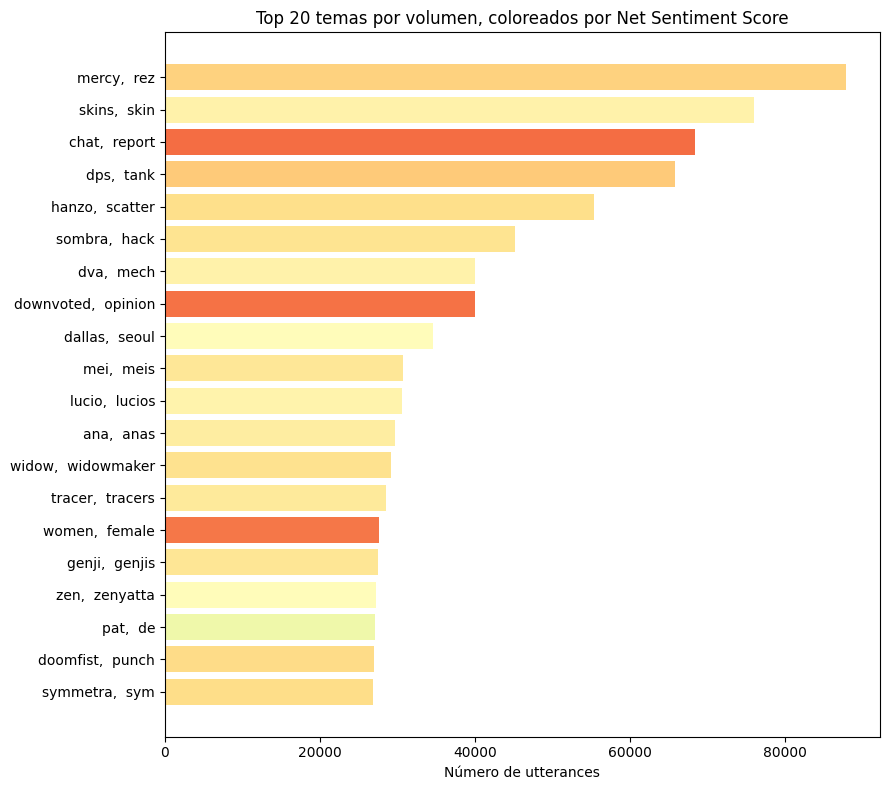

In [6]:
top_n = df_viz.sort_values("n_docs", ascending=False).head(20).sort_values("n_docs")

fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.cm.RdYlGn((top_n["net_sentiment_score"] + 1) / 2)  # rojo=negativo, verde=positivo
ax.barh(top_n["label"], top_n["n_docs"], color=colors)
ax.set_xlabel("Número de utterances")
ax.set_title("Top 20 temas por volumen, coloreados por Net Sentiment Score")
plt.tight_layout()
plt.show()

Mapa de prioridad.

En el cuadrante superior-derecho tenemos temas grandes y bien percibidos (fortalezas a mantener/comunicar).

En el cuadrante inferior derecho tenemos temas grandes y mal percibidos (prioridad de atencion real, mucho volumen, mucha gente afectada, sentimiento negativo)

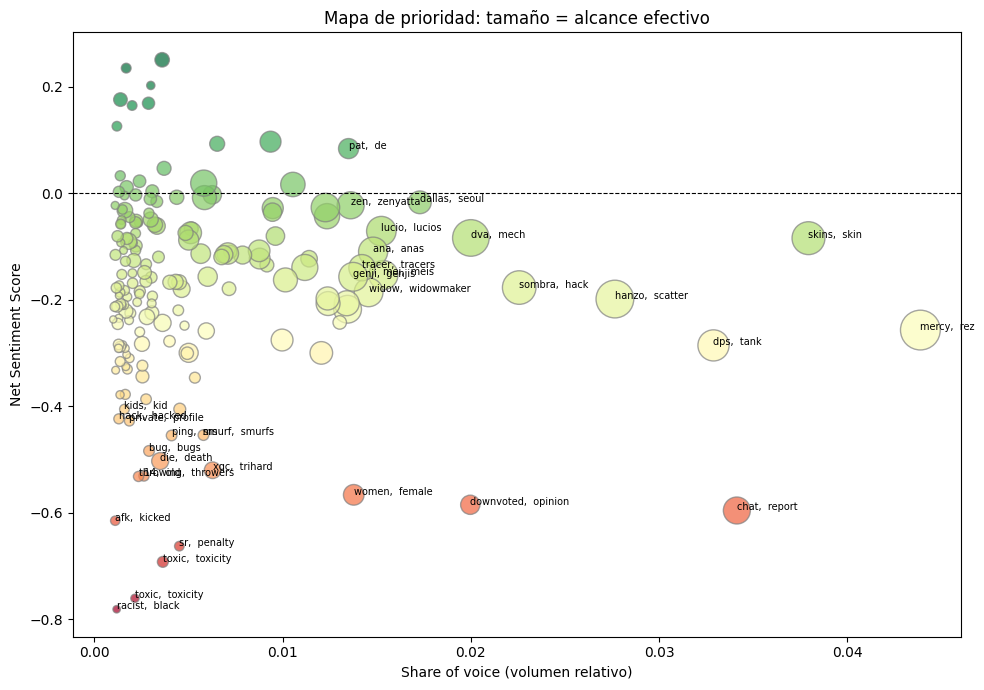

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
sizes = (df_viz["effective_reach"] / df_viz["effective_reach"].max()) * 800 + 20

scatter = ax.scatter(
    df_viz["share_of_voice"], df_viz["net_sentiment_score"],
    s=sizes, c=df_viz["net_sentiment_score"], cmap="RdYlGn", alpha=0.7, edgecolors="grey"
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Share of voice (volumen relativo)")
ax.set_ylabel("Net Sentiment Score")
ax.set_title("Mapa de prioridad: tamaño = alcance efectivo")

# Etiquetar solo los más extremos/grandes para no saturar
destacados = df_viz[(df_viz["share_of_voice"] > df_viz["share_of_voice"].quantile(0.9)) |
                     (df_viz["net_sentiment_score"] < df_viz["net_sentiment_score"].quantile(0.1))]
for _, row in destacados.iterrows():
    ax.annotate(row["label"], (row["share_of_voice"], row["net_sentiment_score"]), fontsize=7)

plt.tight_layout()
plt.show()

Temas mas polarizados/controvertidos.

Complementando al grafico anterior, aqui tenemos temas que en el NSS podrian parecer neutros, pero en realidad dividen a la comunidad entre amor y odio (candidatos interesantes para profundizar con el LLM de resumen con sampleo extendido)

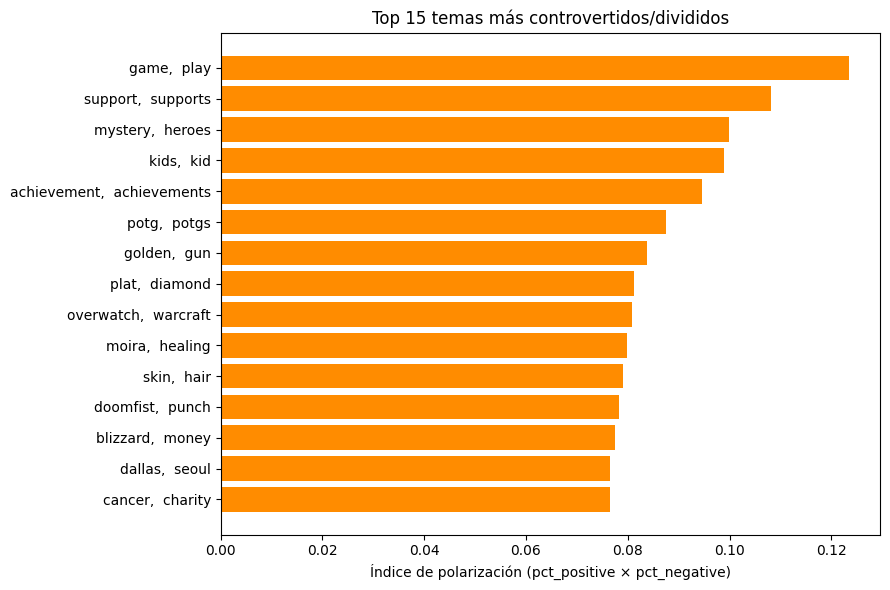

In [8]:
top_polar = df_viz.sort_values("polarization_index", ascending=False).head(15).sort_values("polarization_index")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_polar["label"], top_polar["polarization_index"], color="darkorange")
ax.set_xlabel("Índice de polarización (pct_positive × pct_negative)")
ax.set_title("Top 15 temas más controvertidos/divididos")
plt.tight_layout()
plt.show()

Distribución completa de sentmiento para los temas top. Muestra composicion completa, no solo NSS resumido.

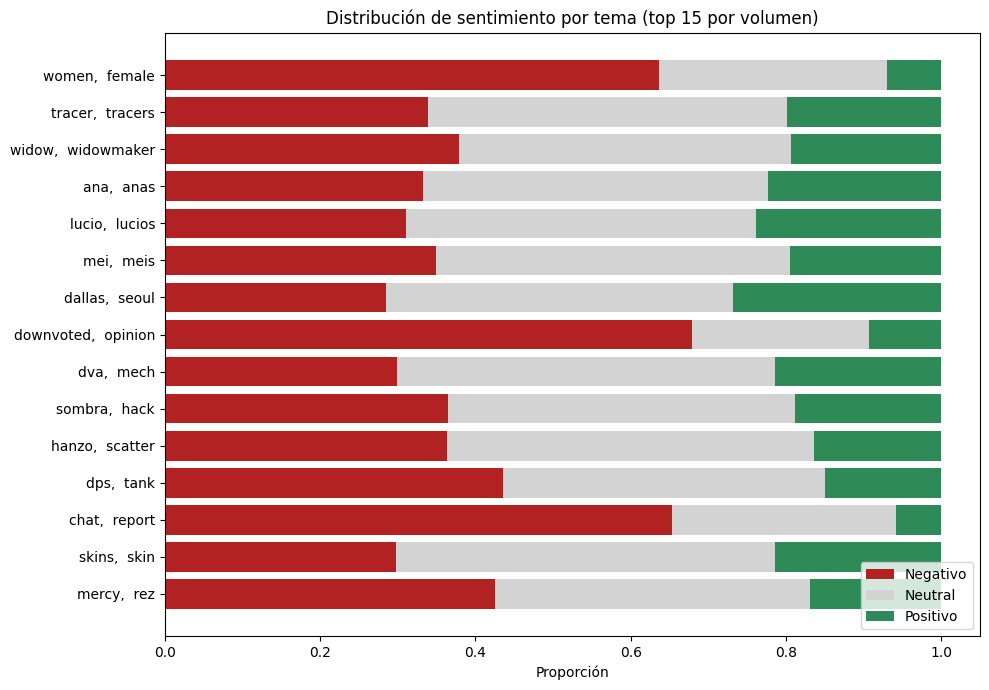

In [ ]:
top_n_stacked = df_viz.sort_values("n_docs", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_n_stacked["label"], top_n_stacked["pct_negative"], color="firebrick", label="Negativo")
ax.barh(top_n_stacked["label"], top_n_stacked["pct_neutral"], left=top_n_stacked["pct_negative"], color="lightgrey", label="Neutral")
ax.barh(top_n_stacked["label"], top_n_stacked["pct_positive"],
        left=top_n_stacked["pct_negative"] + top_n_stacked["pct_neutral"], color="seagreen", label="Positivo")
ax.set_xlabel("Proporción")
ax.set_title("Distribución de sentimiento por tema (top 15 por volumen)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

#Wow vaya resultado 

Concentración de autoria. Para detectar temas dominados por pocas voces. Ayuda a distinguir tema con consenso amplio de la comunidad de tema inflado por unos pocos usuarios muy activos. Esto es relevante para no sobreinterpretar un cluster como 'hot topic' genuino.

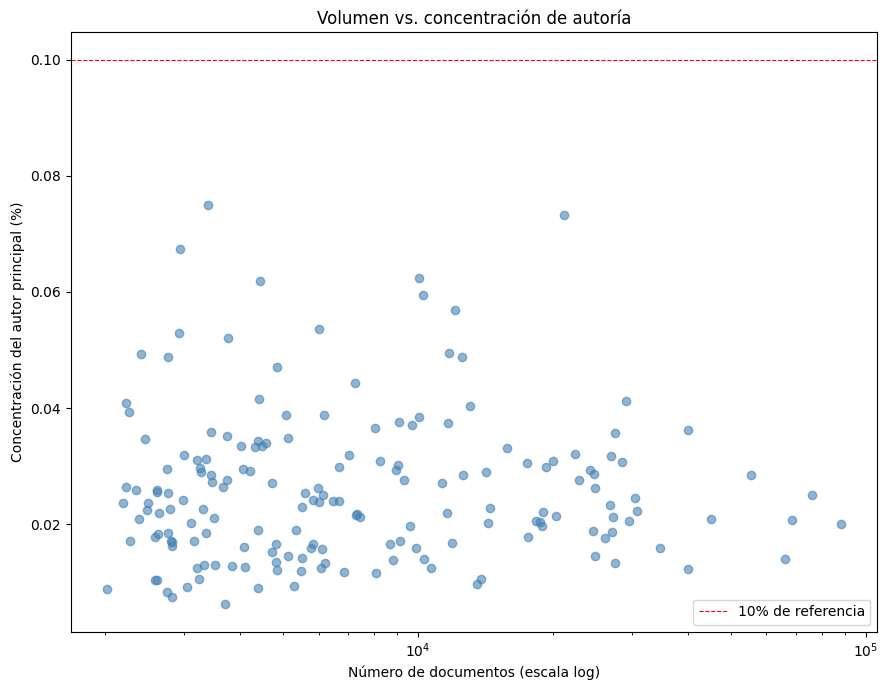

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df_viz["n_docs"], df_viz["author_concentration"], alpha=0.6, c="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Número de documentos (escala log)")
ax.set_ylabel("Concentración del autor principal (%)")
ax.set_title("Volumen vs. concentración de autoría")
ax.axhline(0.1, color="red", linestyle="--", linewidth=0.8, label="10% de referencia")
ax.legend()
plt.tight_layout()
plt.show()

En el despliegue, también sería interesante generar mapas interactivos con funciones hover, por ejemplo para mostrar los resumenes generados con el LLM de cada topi

In [11]:
import plotly.express as px

# Texto de hover: envolver el resumen en varias líneas para que no salga una fila kilométrica
df_viz["summary_wrapped"] = df_viz["llm_summary"].fillna("Sin resumen").str.wrap(60).str.replace("\n", "<br>")

fig = px.scatter(
    df_viz,
    x="share_of_voice",
    y="net_sentiment_score",
    size="effective_reach",
    color="net_sentiment_score",
    color_continuous_scale="RdYlGn",
    hover_name="label",
    hover_data={
        "share_of_voice": ":.3f",
        "net_sentiment_score": ":.3f",
        "n_docs": True,
        "keywords": True,
        "summary_wrapped": True,
        "effective_reach": False,  # ya se ve en el tamaño, no hace falta repetirlo en texto
    },
    title="Mapa de prioridad interactivo (pasa el ratón sobre cada punto)",
)
fig.update_layout(height=650)
fig.show()

También se podrían generar graficas con tablas de referencia cruzada para incluir esos resumenes.

In [12]:
def print_reference_table(df_subset, order_col, ascending=False):
    tabla = df_subset.sort_values(order_col, ascending=ascending)[
        ["label", "keywords", "llm_summary", "n_docs", "net_sentiment_score"]
    ].copy()
    tabla["llm_summary"] = tabla["llm_summary"].str.slice(0, 120) + "..."
    return tabla.reset_index(drop=True)

# Ejemplo de uso, justo después del gráfico 1 (top 20 por volumen)
print_reference_table(df_viz, "n_docs").head(20)

,label,keywords,llm_summary,n_docs,net_sentiment_score
0,"mercy, rez","mercy, rez, her, she, mercys, res, valk, ult, ...",Users are discussing the hero Mercy and her ga...,87909,-0.257039
1,"skins, skin","skins, skin, boxes, loot, event, lootboxes, le...",Users are discussing purchasing skins or loot ...,76004,-0.084377
2,"chat, report","chat, report, banned, ban, reports, voice, rep...",Users are discussing issues related to the rep...,68381,-0.596014
3,"dps, tank","dps, tank, healer, tanks, healing, healers, he...",Users are discussing switching roles from Tank...,65895,-0.285849
4,"hanzo, scatter","hanzo, scatter, hanzos, arrow, arrows, widow, ...",Users are discussing the hero Hanzo in this cl...,55404,-0.198776
5,"sombra, hack","sombra, hack, sombras, her, translocator, she,...","Users are discussing Sombra, a hero in Overwat...",45222,-0.177148
6,"dva, mech","dva, mech, dvas, meka, her, baby, she, bomb, u...",Users are discussing the hero D.va and her gam...,40078,-0.083961
7,"downvoted, opinion","downvoted, opinion, downvotes, upvote, karma, ...",Users are discussing the issue of downvoting c...,40013,-0.585285
8,"dallas, seoul","dallas, seoul, london, korean, teams, fuel, ny...",The users are discussing matches and teams in ...,34651,-0.017027
9,"mei, meis","mei, meis, freeze, ice, wall, her, frozen, she...",Users are discussing their choice of playing t...,30767,-0.153671


Por ultimo vamos a crear un gold set etiquetado manualmente para ver como se comporta la inferencia.

In [3]:
import pandas as pd
import numpy as np

DIR = r"D:\TFM\data\Overwatch.corpus\overwatch_final_dataset_with_sentiment.parquet"

# 1. Cargar el dataset que YA tiene las predicciones del modelo
# Reemplaza 'tus_predicciones.parquet' (o .csv) por la ruta de tus datos
df = pd.read_parquet(DIR) 

# 1. Configurar nombres de columnas exactos de tu DataFrame
COL_TEXTO = 'text_for_sentiment'  # o 'raw_text', según prefieras leer para etiquetar
COL_PREDICCION = 'sentiment_label'

# 2. Guardar proporciones reales del corpus
proporciones_poblacion = df[COL_PREDICCION].value_counts(normalize=True).to_dict()
print("Proporciones reales en el corpus:")
for clase, prop in proporciones_poblacion.items():
    print(f" - {clase}: {prop:.2%}")

# 3. Muestreo estratificado limpio (Muestra N por cada categoría de sentiment_label)
MUESTRAS_POR_CLASE = 60

gold_sample = (
    df.groupby(COL_PREDICCION, as_index=False)
      .sample(n=MUESTRAS_POR_CLASE, random_state=42)
      .copy()
)

# 4. Añadir la columna vacía para tu etiquetado manual
gold_sample['sentimiento_real'] = ''

# 5. Seleccionar las columnas que quieres ver en el archivo
columnas_exportar = [COL_TEXTO, COL_PREDICCION, 'sentimiento_real']
df_export = gold_sample[columnas_exportar]

# 6. Exportar
df_export.to_csv('gold_set_estratificado.csv', index=False, encoding='utf-8-sig')

print(f"\n¡Exportado con éxito! Total de filas: {len(df_export)}")
print("Distribución por clase en el archivo exportado:")
print(df_export[COL_PREDICCION].value_counts())

Proporciones reales en el corpus:
 - neutral: 45.56%
 - negative: 36.52%
 - positive: 17.93%

¡Exportado con éxito! Total de filas: 180
Distribución por clase en el archivo exportado:
sentiment_label
negative    60
neutral     60
positive    60
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Cargar el dataset original (para recuperar las proporciones reales de la población)
# Ajusta la ruta o variable si ya tienes el DataFrame cargado en memoria
df_original = pd.read_parquet(DIR) 
COL_PREDICCION = 'sentiment_label'

# Proporciones reales en tus 3.8M de filas
proporciones_poblacion = df_original[COL_PREDICCION].value_counts(normalize=True).to_dict()

# 2. Cargar el Gold Set que has etiquetado manualmente
df_gold = pd.read_csv(r'D:\TFM\notebooks3\gold_set_clasificado.csv')

# Filtrar posibles filas vacías o no etiquetadas
df_gold = df_gold[df_gold['sentimiento_real'].notna() & (df_gold['sentimiento_real'] != '')].copy()

# Normalizar texto (espacios/minúsculas) por si hubo erratas al escribir a mano
df_gold['sentimiento_real'] = df_gold['sentimiento_real'].astype(str).str.strip().str.lower()
df_gold[COL_PREDICCION] = df_gold[COL_PREDICCION].astype(str).str.strip().str.lower()

y_true = df_gold['sentimiento_real']
y_pred = df_gold[COL_PREDICCION]
labels = sorted(list(set(y_true.unique()).union(set(y_pred.unique()))))

# --- REPORTES Y MÉTRICAS ---

print("="*60)
print(" 1. REPORTE DE CLASIFICACIÓN POR CLASE (Muestra Balances)")
print("="*60)
print(classification_report(y_true, y_pred, digits=4))

print("="*60)
print(" 2. MATRIZ DE CONFUSIÓN")
print("="*60)
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(
    cm, 
    index=[f'Real: {l}' for l in labels], 
    columns=[f'Pred: {l}' for l in labels]
)
print(cm_df)

# 3. Accuracy Ajustado (Ponderado por la Población Real)
recalls = {}
for i, label in enumerate(labels):
    tp = cm[i, i]
    fn = sum(cm[i, :]) - tp
    recalls[label] = tp / (tp + fn) if (tp + fn) > 0 else 0

accuracy_ajustado = sum(recalls.get(clase, 0) * proporciones_poblacion.get(clase, 0) for clase in labels)

print("\n" + "="*60)
print(f" 3. ACCURACY GLOBAL AJUSTADO A POBLACIÓN REAL: {accuracy_ajustado:.4%}")
print("="*60)

 1. REPORTE DE CLASIFICACIÓN POR CLASE (Muestra Balances)
              precision    recall  f1-score   support

    negative     0.8667    0.8966    0.8814        58
     neutral     0.9167    0.8871    0.9016        62
    positive     0.9833    0.9833    0.9833        60

    accuracy                         0.9222       180
   macro avg     0.9222    0.9223    0.9221       180
weighted avg     0.9228    0.9222    0.9223       180

 2. MATRIZ DE CONFUSIÓN
                Pred: negative  Pred: neutral  Pred: positive
Real: negative              52              5               1
Real: neutral                7             55               0
Real: positive               1              0              59

 3. ACCURACY GLOBAL AJUSTADO A POBLACIÓN REAL: 90.7803%
